# Telco Customer Churn — Preprocessing

Du CSV brut à un jeu de données propre, prêt à modéliser.

In [43]:
%pip install pandas

import pandas as pd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Phase 0 — Récupérer la donnée et l'ouvrir

In [44]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [45]:
## Phase 1 — L'audit qualité

In [46]:
def audit_qualite(df):
    """Affiche un rapport de santé du dataset.

    Doit montrer : forme, types, % de manquants par colonne (triés),
    et la répartition de la cible Churn (en valeur ET en pourcentage).
    """
    print(f"Forme : {df.shape}")
    print()

    manquants = (df.isna().mean() * 100).sort_values(ascending=False)
    cols_avec_trous = manquants[manquants > 0]

    if len(cols_avec_trous) == 0:
        print("Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)")
    else:
        print("Manquants par colonne (%) :")
        for col, pct in cols_avec_trous.items():
            print(f"  {col} : {pct:.1f}%")

    print()

    if "Churn" not in df.columns:
        print("Colonne Churn absente.")
        return

    if len(df) == 0:
        print("Dataset vide.")
        return

    repartition = df["Churn"].value_counts()
    total = len(df)

    for val, count in repartition.items():
        pct = 100 * count / total
        print(f"Churn  {val} : {count} ({pct:.1f}%)")

In [47]:
print("=== Cas normal : dataset complet ===")
audit_qualite(df)

=== Cas normal : dataset complet ===
Forme : (7043, 21)

Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)

Churn  No : 5174 (73.5%)
Churn  Yes : 1869 (26.5%)


In [48]:
print("=== Cas limite : une seule classe (Churn == No) ===")
df_une_classe = df[df["Churn"] == "No"]
audit_qualite(df_une_classe)

=== Cas limite : une seule classe (Churn == No) ===
Forme : (5174, 21)

Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)

Churn  No : 5174 (100.0%)


In [49]:
print("=== Cas adversarial : déséquilibre visible ? ===")
repartition = df["Churn"].value_counts(normalize=True) * 100
print(repartition.round(1))
print()
print("→ 73/27 : le churn est minoritaire. L'accuracy seule sera trompeuse demain.")

=== Cas adversarial : déséquilibre visible ? ===
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

→ 73/27 : le churn est minoritaire. L'accuracy seule sera trompeuse demain.


In [50]:
## Phase 2 — La colonne piégée (TotalCharges)

In [51]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés.

    Doit renvoyer le df réparé et afficher combien de trous ont été démasqués.
    """
    df = df.copy()

    avant = df["TotalCharges"].isna().sum()
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
    apres = df["TotalCharges"].isna().sum()
    trous_demasques = apres - avant

    print(f"Trous démasqués : {trous_demasques}")
    print(f"Type après conversion : {df['TotalCharges'].dtype}")

    if trous_demasques > 0:
        mediane = df["TotalCharges"].median()
        df["TotalCharges"] = df["TotalCharges"].fillna(mediane)
        print(f"Imputation par la médiane : {mediane:.2f}")

    return df

In [52]:
df = reparer_total_charges(df)
print(f"\nForme finale : {df.shape}")
print(df["TotalCharges"].dtype)

Trous démasqués : 11
Type après conversion : float64
Imputation par la médiane : 1397.47

Forme finale : (7043, 21)
float64


In [53]:
print("=== Edge case : colonne 100% texte ===")
df_test = pd.DataFrame({"col_texte": ["abc", "def", "ghi"]})
converti = pd.to_numeric(df_test["col_texte"], errors="coerce")
if converti.isna().all():
    print("→ 100% non numérique : on refuse de l'utiliser comme feature numérique.")

=== Edge case : colonne 100% texte ===
→ 100% non numérique : on refuse de l'utiliser comme feature numérique.


In [54]:
print("=== Adversarial : virgule au lieu du point (29,90) ===")
df_test2 = pd.DataFrame({"MonthlyCharges": ["29.90", "29,90", "45.00"]})
converti2 = pd.to_numeric(df_test2["MonthlyCharges"], errors="coerce")
print(converti2)


=== Adversarial : virgule au lieu du point (29,90) ===
0    29.9
1     NaN
2    45.0
Name: MonthlyCharges, dtype: float64


**Choix : imputation par médiane** (pas suppression des 11 lignes).

- On ne perd aucun client churn.
- 11 lignes sur 7043, impact négligeable.
- La médiane est robuste aux valeurs extrêmes.

## Phase 3 — Encoder les catégorielles

In [55]:
def encoder_features(df):
    """Encode toutes les colonnes catégorielles.

    Doit renvoyer un df 100% numérique, prêt pour un modèle.
    """
    df = df.copy()
    nb_avant = df.shape[1]

    # customerID = identifiant, pas une feature
    df = df.drop(columns=["customerID"])

    # cible binaire
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

    # colonnes Yes/No simples → 0/1
    for col in df.columns:
        if df[col].dtype == "object" or str(df[col].dtype) == "str":
            valeurs = set(df[col].dropna().unique())
            if valeurs <= {"Yes", "No"}:
                df[col] = df[col].map({"Yes": 1, "No": 0})

    # le reste (nominales) → One-Hot
    cols_texte = [c for c in df.columns if df[c].dtype == "object" or str(df[c].dtype) == "str"]
    df = pd.get_dummies(df, columns=cols_texte, dtype=int)

    print(f"Colonnes avant : {nb_avant} → après : {df.shape[1]}")
    print(f"Toutes numériques : {df.select_dtypes(exclude='number').shape[1] == 0}")

    return df

In [56]:
print(f"Avant encodage : {df.shape}")
df = encoder_features(df)
print(f"Après encodage : {df.shape}")
df.head()

Avant encodage : (7043, 21)
Colonnes avant : 21 → après : 42
Toutes numériques : True
Après encodage : (7043, 42)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Female,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,1,...,1,0,0,1,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,1889.50,0,0,...,1,0,0,0,1,0,0,0,0,1
2,0,0,0,2,1,1,53.85,108.15,1,0,...,1,0,0,1,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,1840.75,0,0,...,1,0,0,0,1,0,1,0,0,0
4,0,0,0,2,1,1,70.70,151.65,1,1,...,1,0,0,1,0,0,0,0,1,0


**Contract : nominal ou ordinal ?**

Les 3 modalités (Month-to-month, One year, Two year) ont un ordre métier, mais on choisit **One-Hot** : pas de supposer que "Two year" = 2× "One year" en distance. Chaque contrat est une catégorie distincte.

In [57]:
print("=== Adversarial : si on encodait customerID en One-Hot ===")
print(f"→ {df.shape[0]} colonnes créées (1 par client). Explosion de dimensions.")
print("→ C'est pourquoi on supprime les identifiants avant l'encodage.")

=== Adversarial : si on encodait customerID en One-Hot ===
→ 7043 colonnes créées (1 par client). Explosion de dimensions.
→ C'est pourquoi on supprime les identifiants avant l'encodage.


## Phase 4 — Traiter les valeurs aberrantes

In [58]:
%pip install matplotlib

import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
def detecter_outliers_iqr(df, colonne):
    """Renvoie les bornes IQR et le nombre d'outliers d'une colonne numérique.

    Doit renvoyer (borne_basse, borne_haute, nombre_outliers).
    """
    q1 = df[colonne].quantile(0.25)
    q3 = df[colonne].quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    outliers = (df[colonne] < borne_basse) | (df[colonne] > borne_haute)
    return borne_basse, borne_haute, outliers.sum()

In [60]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in colonnes_num:
    bb, bh, n = detecter_outliers_iqr(df, col)
    print(f"{col} : bornes [{bb:.2f}, {bh:.2f}] — {n} outlier(s)")

tenure : bornes [-60.00, 124.00] — 0 outlier(s)
MonthlyCharges : bornes [-46.02, 171.38] — 0 outlier(s)
TotalCharges : bornes [-4674.34, 8863.16] — 0 outlier(s)


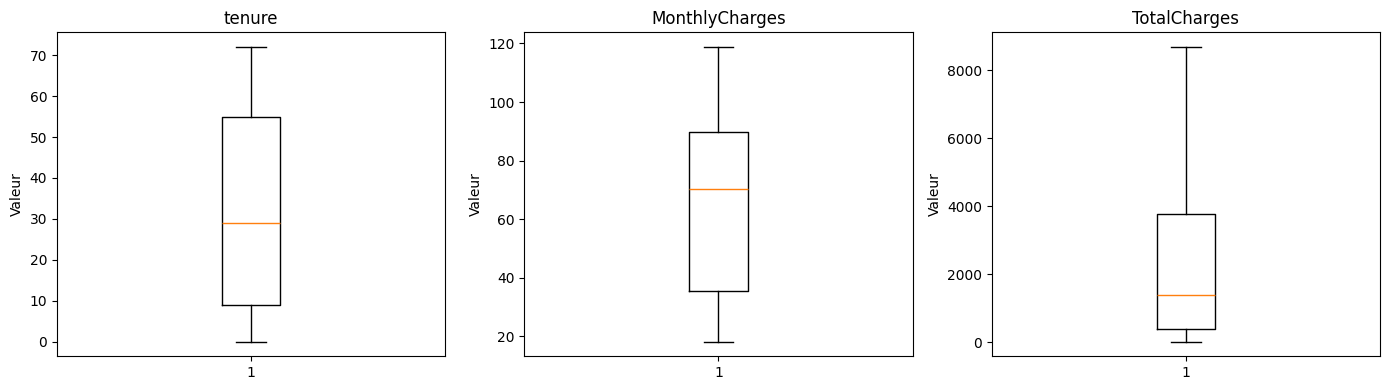

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, colonnes_num):
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_ylabel("Valeur")

plt.tight_layout()
plt.show()

**Décision : on garde tous les outliers.**

- `tenure` : 0 outlier IQR — ancienneté longue = client fidèle, pas une erreur.
- `MonthlyCharges` : 0 outlier IQR — facture élevée = client rentable ou à risque, cas réel.
- `TotalCharges` : 0 outlier IQR — lié à tenure × mensuel, pas une corruption.

On ne supprime ni ne plafonne : ce sont des signaux métier, pas du bruit.

In [62]:
print("=== Edge case : colonne sans outlier ===")
bb, bh, n = detecter_outliers_iqr(df, "SeniorCitizen")
print(f"SeniorCitizen : {n} outlier(s) ")

print("\n=== Si on supprimait quand même les outliers des 3 colonnes ===")
masque = pd.Series(False, index=df.index)
for col in colonnes_num:
    bb, bh, n = detecter_outliers_iqr(df, col)
    masque |= (df[col] < bb) | (df[col] > bh)

churn_perdus = df[masque & (df["Churn"] == 1)].shape[0]
total_churn = (df["Churn"] == 1).sum()
print(f"Clients churn supprimés : {churn_perdus} / {total_churn} ({100 * churn_perdus / total_churn:.1f}%)")

=== Edge case : colonne sans outlier ===
SeniorCitizen : 1142 outlier(s) 

=== Si on supprimait quand même les outliers des 3 colonnes ===
Clients churn supprimés : 0 / 1869 (0.0%)


In [63]:
## Phase 5 — Corrélations et multicolinéarité

In [64]:
%pip install seaborn statsmodels

import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
def rapport_multicolinearite(df, colonnes_num):
    """Affiche la heatmap des corrélations et le VIF de chaque colonne numérique.

    Doit aider à décider quelle(s) colonne(s) redondante(s) supprimer.
    """
    corr = df[colonnes_num].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Corrélations")
    plt.tight_layout()
    plt.show()

    vifs = []
    X = df[colonnes_num]

    for i, col in enumerate(colonnes_num):
        vif = variance_inflation_factor(X.values, i)
        vifs.append({"colonne": col, "VIF": vif})

    vif_df = pd.DataFrame(vifs).sort_values("VIF", ascending=False)
    print(vif_df.to_string(index=False))

    alerte = vif_df[vif_df["VIF"] > 5]
    if len(alerte) > 0:
        print(f"\nColonnes au VIF > 5 : {list(alerte['colonne'])}")
    else:
        print("\nAucune colonne au VIF > 5")

    return vif_df

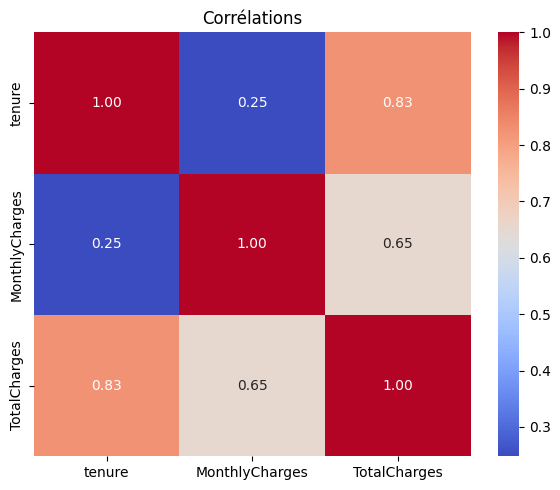

       colonne      VIF
  TotalCharges 8.073814
        tenure 6.321802
MonthlyCharges 3.360371

Colonnes au VIF > 5 : ['TotalCharges', 'tenure']


In [66]:
colonnes_vif = ["tenure", "MonthlyCharges", "TotalCharges"]

vif_df = rapport_multicolinearite(df, colonnes_vif)

=== Suppression de TotalCharges (redondant avec tenure × MonthlyCharges) ===


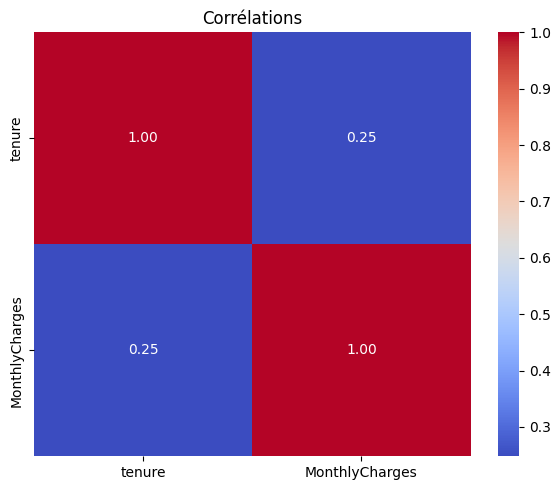

       colonne      VIF
MonthlyCharges 2.612607
        tenure 2.612607

Aucune colonne au VIF > 5


,colonne,VIF
1,MonthlyCharges,2.612607
0,tenure,2.612607


In [67]:
print("=== Suppression de TotalCharges (redondant avec tenure × MonthlyCharges) ===")
df = df.drop(columns=["TotalCharges"])
colonnes_vif = ["tenure", "MonthlyCharges"]

rapport_multicolinearite(df, colonnes_vif)

In [68]:
print("=== Edge case : deux colonnes identiques ===")
df_test = df[["tenure", "MonthlyCharges"]].copy()
df_test["tenure_duplique"] = df_test["tenure"]

try:
    for i, col in enumerate(["tenure", "MonthlyCharges", "tenure_duplique"]):
        v = variance_inflation_factor(df_test.values, i)
        print(f"{col} : VIF = {v:.1f}")
except Exception as e:
    print(f"→ VIF explose ou erreur (colonne parfaite) : {e}")

=== Edge case : deux colonnes identiques ===
tenure : VIF = inf
MonthlyCharges : VIF = 2.6
tenure_duplique : VIF = inf


c:\Python311\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## Phase 6 — Features discriminantes

In [69]:
%pip install scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
def features_discriminantes(df, cible="Churn"):
    """Classe les features par pouvoir prédictif sur la cible.

    Doit afficher un top 10 selon au moins deux méthodes.
    """
    X = df.drop(columns=[cible])
    y = df[cible]

    corr = X.corrwith(y).abs().sort_values(ascending=False)

    mi = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    rf_series = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    print("=== Top 10 — |corrélation| avec Churn ===")
    print(corr.head(10).to_string())

    print("\n=== Top 10 — Information mutuelle ===")
    print(mi_series.head(10).to_string())

    print("\n=== Top 10 — Random Forest ===")
    print(rf_series.head(10).to_string())

    return corr, mi_series, rf_series

In [71]:
features_discriminantes(df)

=== Top 10 — |corrélation| avec Churn ===
Contract_Month-to-month               0.405103
tenure                                0.352229
OnlineSecurity_No                     0.342637
TechSupport_No                        0.337281
InternetService_Fiber optic           0.308020
Contract_Two year                     0.302253
PaymentMethod_Electronic check        0.301919
OnlineBackup_No                       0.268005
DeviceProtection_No                   0.252481
OnlineSecurity_No internet service    0.227890

=== Top 10 — Information mutuelle ===
Contract_Month-to-month                 0.088743
tenure                                  0.072696
OnlineSecurity_No                       0.063804
TechSupport_No                          0.060900
Contract_Two year                       0.054476
InternetService_Fiber optic             0.049838
MonthlyCharges                          0.048635
OnlineBackup_No                         0.043158
PaymentMethod_Electronic check          0.042957
DevicePr

(Contract_Month-to-month                    0.405103
 tenure                                     0.352229
 OnlineSecurity_No                          0.342637
 TechSupport_No                             0.337281
 InternetService_Fiber optic                0.308020
 Contract_Two year                          0.302253
 PaymentMethod_Electronic check             0.301919
 OnlineBackup_No                            0.268005
 DeviceProtection_No                        0.252481
 OnlineSecurity_No internet service         0.227890
 TechSupport_No internet service            0.227890
 StreamingTV_No internet service            0.227890
 InternetService_No                         0.227890
 OnlineBackup_No internet service           0.227890
 DeviceProtection_No internet service       0.227890
 StreamingMovies_No internet service        0.227890
 MonthlyCharges                             0.193356
 PaperlessBilling                           0.191825
 Contract_One year                          0.

**Lecture métier :** `Contract_Month-to-month` et `tenure` ressortent souvent en tête.

Les clients en contrat mensuel et récents partent plus — logique business : pas d'engagement, facile de résilier.

## Phase 7 — Split, scaling, et le grand piège de la fuite

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

In [73]:
def split_et_scale_proprement(X, y):
    """Sépare train/test PUIS ajuste le scaler sur le train seul.

    Doit renvoyer X_train_scaled, X_test_scaled, y_train, y_test.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [74]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train_s, X_test_s, y_train, y_test = split_et_scale_proprement(X, y)

modele = LogisticRegression(max_iter=1000, random_state=42)
modele.fit(X_train_s, y_train)
y_pred = modele.predict(X_test_s)

acc_honnete = accuracy_score(y_test, y_pred)
recall_honnete = recall_score(y_test, y_pred)

print(f"Version honnête (scaler fit train) :")
print(f"  Accuracy : {acc_honnete:.1%}")
print(f"  Recall churn (classe 1) : {recall_honnete:.1%}")

Version honnête (scaler fit train) :
  Accuracy : 79.7%
  Recall churn (classe 1) : 55.1%


In [75]:
print("=== Démo data leakage : scaler fit sur TOUT X avant split ===")

scaler_triche = StandardScaler()
X_scaled_triche = scaler_triche.fit_transform(X)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_scaled_triche, y, test_size=0.2, random_state=42, stratify=y
)

modele_triche = LogisticRegression(max_iter=1000, random_state=42)
modele_triche.fit(X_train_t, y_train_t)
y_pred_t = modele_triche.predict(X_test_t)

acc_triche = accuracy_score(y_test_t, y_pred_t)
recall_triche = recall_score(y_test_t, y_pred_t)

print(f"Accuracy triche   : {acc_triche:.1%}  (delta {acc_triche - acc_honnete:+.1%})")
print(f"Recall churn triche : {recall_triche:.1%}")
print("\n→ Le scaler a vu les stats du test. Sur 7000 lignes l'écart est minuscule, mais le réflexe reste : fit TOUJOURS sur le train seul.")

=== Démo data leakage : scaler fit sur TOUT X avant split ===
Accuracy triche   : 79.7%  (delta +0.0%)
Recall churn triche : 55.1%

→ Le scaler a vu les stats du test. Sur 7000 lignes l'écart est minuscule, mais le réflexe reste : fit TOUJOURS sur le train seul.


## Phase 8 — Le bilan

In [76]:
recap = pd.DataFrame({
    "Étape": ["Avant", "Après encodage", "Après VIF", "Final"],
    "Colonnes": [21, 42, 41, df.shape[1]],
    "Lignes": [7043, 7043, 7043, df.shape[0]],
    "Note": [
        "CSV brut",
        "One-Hot + Yes/No",
        "TotalCharges supprimé",
        "Prêt à modéliser",
    ],
})
print("=== Tableau de bord du nettoyage ===")
print(recap.to_string(index=False))

=== Tableau de bord du nettoyage ===
         Étape  Colonnes  Lignes                  Note
         Avant        21    7043              CSV brut
Après encodage        42    7043      One-Hot + Yes/No
     Après VIF        41    7043 TotalCharges supprimé
         Final        41    7043      Prêt à modéliser


In [77]:
print("=== Baseline : accuracy vs recall churn ===")
print(f"Accuracy seule : {acc_honnete:.1%}")
print(f"Recall churn   : {recall_honnete:.1%}")
print(f"Dummy (toujours 'Non') : {(y_test == 0).mean():.1%} accuracy — trompeur sur du 73/27")
print("\n→ Sur du déséquilibré, le recall churn compte plus que l'accuracy seule.")

=== Baseline : accuracy vs recall churn ===
Accuracy seule : 79.7%
Recall churn   : 55.1%
Dummy (toujours 'Non') : 73.5% accuracy — trompeur sur du 73/27

→ Sur du déséquilibré, le recall churn compte plus que l'accuracy seule.


Composantes pour 90% de variance : 16


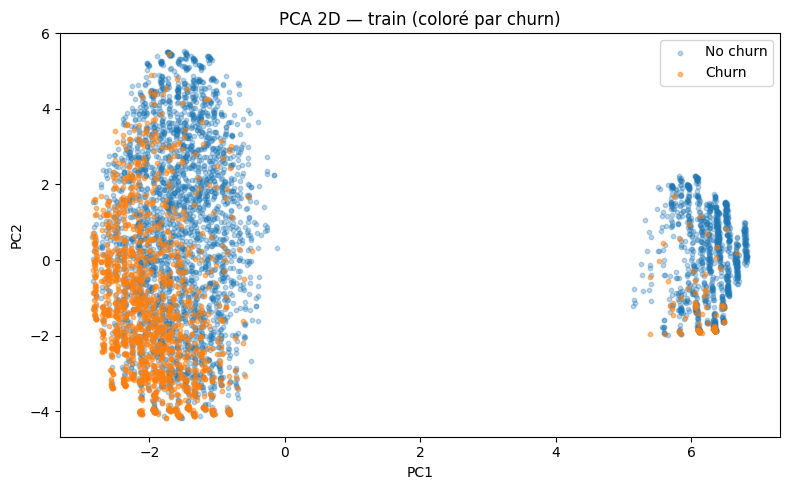

In [78]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_s)

var_cum = pca.explained_variance_ratio_.cumsum()
n_90 = (var_cum >= 0.9).argmax() + 1
print(f"Composantes pour 90% de variance : {n_90}")

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_train_s)

plt.figure(figsize=(8, 5))
plt.scatter(X_2d[y_train == 0, 0], X_2d[y_train == 0, 1], alpha=0.3, label="No churn", s=10)
plt.scatter(X_2d[y_train == 1, 0], X_2d[y_train == 1, 1], alpha=0.5, label="Churn", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D — train (coloré par churn)")
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
modele_final = LogisticRegression(max_iter=1000, random_state=42)
modele_final.fit(X_train_s, y_train)
pred_final = modele_final.predict(X_test_s)

print(f"fit OK — predict OK")
print(f"Accuracy test : {accuracy_score(y_test, pred_final):.1%}")
print(f"Recall churn  : {recall_score(y_test, pred_final):.1%}")


fit OK — predict OK
Accuracy test : 79.7%
Recall churn  : 55.1%
